# Baseline model
## 1. Define the Data Generators

In [2]:
import os
from keras.utils import image_dataset_from_directory

batch_size = 32
image_size = (150, 150)

base_dir = '.'
data_dir = os.path.join(base_dir, "dataset", "signlang_v2")

#base paths from the datasets
train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

#creating the datasets
train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical", #categorical because we're dealing with many classes
    shuffle=True
)

validation_dataset = image_dataset_from_directory(
    val_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

epochs = 10

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Found 1702 files belonging to 10 classes.
Found 548 files belonging to 10 classes.
Found 287 files belonging to 10 classes.


## 2. Test the generators

In [3]:
for data_batch, label_batch in train_dataset:
    print('data batch shape ', data_batch.shape)
    print('label batch shape ', label_batch.shape)
    print('sample data shape ', data_batch[0].shape)
    print('sample labels ', label_batch[:10].numpy()) #show the first 10 labels

    break

data batch shape  (32, 150, 150, 3)
label batch shape  (32, 10)
sample data shape  (150, 150, 3)
sample labels  [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]



## 3. Images from the dataset

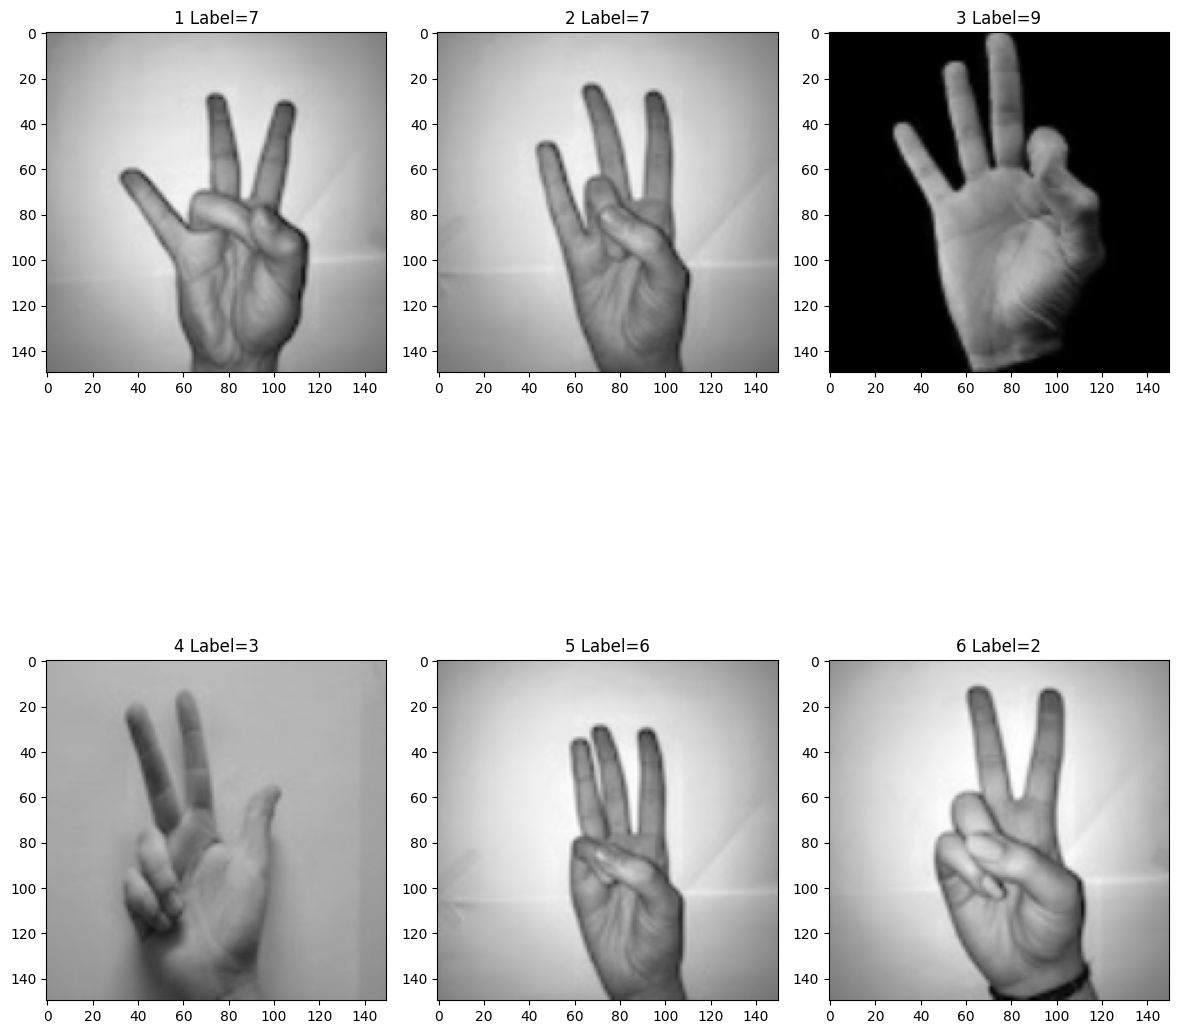

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig=plt.figure(figsize=(12,15))
columns = 3
rows = 2

for i in range(1, 7):
    img = data_batch[i]/255
    ax =fig.add_subplot(rows, columns, i)

    lbl = str(np.argmax(label_batch[i]))

    fig.tight_layout()
    ax.title.set_text(str(i)+ " Label=" + lbl)
    plt.imshow(img)
plt.show()


## 4.  Define the network with single layers

In [5]:

from keras import models, layers

network = models.Sequential()
network.add(layers.Input(shape= (150,150,3)))
network.add(layers.Rescaling(1.0/255))

network.add(layers.Conv2D(32, (3,3), activation='relu'))
network.add(layers.MaxPooling2D(2,2))

network.add(layers.Flatten())

network.add(layers.Dense(10, activation='softmax'))

network.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │     1,752,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,753,226 (6.69 MB)

 Trainable params: 1,753,226 (6.69 MB)

 Non-trainable params: 0 (0.00 B)


## 5. Compile and Train

In [6]:

network.compile(loss='categorical_crossentropy', optimizer="adam", metrics=['acc'])

history = network.fit(train_dataset, epochs=epochs, validation_data=validation_dataset)
network.save("convnet_base.keras")
print("Saved model")

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - acc: 0.2808 - loss: 5.0704 - val_acc: 0.4179 - val_loss: 1.7996
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - acc: 0.7632 - loss: 1.0293 - val_acc: 0.6715 - val_loss: 1.0601
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - acc: 0.9054 - loss: 0.5004 - val_acc: 0.7208 - val_loss: 0.8441
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - acc: 0.9448 - loss: 0.3153 - val_acc: 0.7299 - val_loss: 0.7956
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - acc: 0.9765 - loss: 0.1987 - val_acc: 0.7427 - val_loss: 0.7408
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - acc: 0.9882 - loss: 0.1351 - val_acc: 0.7372 - val_loss: 0.7991
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 203ms/step - acc: 0.9941 - loss: 0.0915 - val_acc: 0.7573 - val_loss: 0.7165
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - acc: 0.9982 - loss: 0.0649 - val_acc: 0.7536 - val_loss: 0.7487
Epoch 9/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 166ms/ste


## 6. Graphs

In [7]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_list = range(1, len(acc)+1)

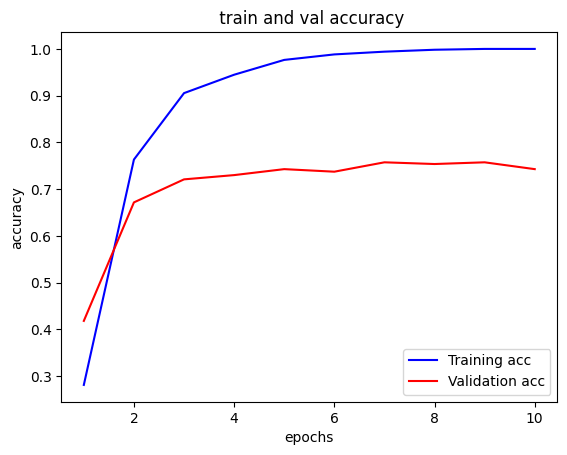

In [8]:
plt.plot(epochs_list, acc, 'b', label='Training acc')
plt.plot(epochs_list, val_acc, 'r', label='Validation acc')
plt.title(' train and val accuracy')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

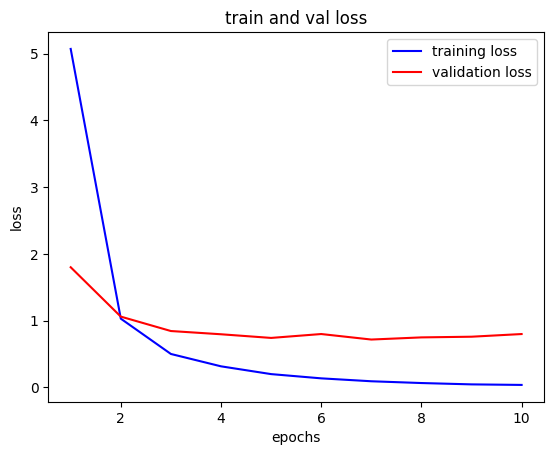

In [9]:
plt.plot(epochs_list, loss, 'b', label='training loss')
plt.plot(epochs_list, val_loss, 'r', label='validation loss')
plt.title('train and val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()


## 7. Test Accuracy

In [10]:
from keras import models

test_model = models.load_model("convnet_base.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test loss: {test_loss:.3f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.8049 - loss: 0.6720
Test accuracy: 0.805
Test loss: 0.672



## 8. Confusion matrix

Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
y_test: 287 y_pred: 287


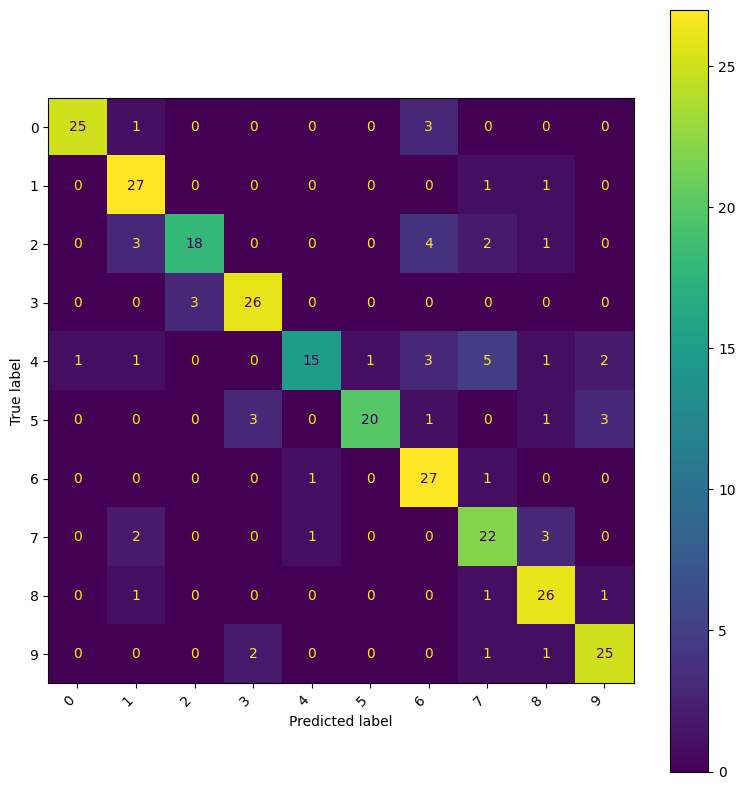

              precision    recall  f1-score   support

           0       0.96      0.86      0.91        29
           1       0.77      0.93      0.84        29
           2       0.86      0.64      0.73        28
           3       0.84      0.90      0.87        29
           4       0.88      0.52      0.65        29
           5       0.95      0.71      0.82        28
           6       0.71      0.93      0.81        29
           7       0.67      0.79      0.72        28
           8       0.76      0.90      0.83        29
           9       0.81      0.86      0.83        29

    accuracy                           0.80       287
   macro avg       0.82      0.80      0.80       287
weighted avg       0.82      0.80      0.80       287



In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from keras import models

def display_confusion_matrix(y_test, y_pred, labels):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, values_format='d')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

test_model = models.load_model("convnet_base.keras")

labels = test_dataset.class_names
print("Class names:", labels)

y_test = np.concatenate([
    np.argmax(y, axis=1) for x, y in test_dataset.as_numpy_iterator()
])

predicted = test_model.predict(test_dataset, verbose=0)
y_pred = np.argmax(predicted, axis=1)

print("y_test:", len(y_test), "y_pred:", len(y_pred))

#classification report
display_confusion_matrix(y_test, y_pred, labels)
print(classification_report(y_test, y_pred, target_names=labels))
